# Classification (with Pytorch)
There exist a lot of tutorials for classification tasks with PyTorch.
The focus of this Jupyter Notebook is: use a simple algorithm which shows the following steps:
- data loading
- batch loading
- network design
- training the neural network with training-, validation- and test-data
- Inference: predicting/classification of a single waveform

In [15]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchaudio import datasets
import torchaudio
from torchaudio.datasets import SPEECHCOMMANDS
import torch.nn.functional as F
import os
import matplotlib.pyplot as plt
import numpy as np

## Data loading
The Google speech command set <cite>Speech Commands: A Dataset for Limited-Vocabulary Speech Recognition</cite> is the standard audio data for training keyword spotter.
The following code downloads the dataset and defines interfaces for accessing the data divided into the three sets
- training,
- validation and
- test.

In [16]:
# source: https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/c64f4bad00653411821adcb75aea9015/speech_command_classification_with_torchaudio_tutorial.ipynb

SR = 16000

class SubsetSC(SPEECHCOMMANDS):
    def __init__(self, subset: str = None):
        super().__init__("./", download=True)

        def load_list(filename):
            filepath = os.path.join(self._path, filename)
            with open(filepath) as fileobj:
                return [os.path.normpath(os.path.join(self._path, line.strip())) for line in fileobj]

        if subset == "validation":
            self._walker = load_list("validation_list.txt")
        elif subset == "testing":
            self._walker = load_list("testing_list.txt")
        elif subset == "training":
            excludes = load_list("validation_list.txt") + load_list("testing_list.txt")
            excludes = set(excludes)
            self._walker = [w for w in self._walker if w not in excludes]

    def __getitem__(self, n:int):
        waveform, sample_rate, label, speaker_id, utterance_number = super().__getitem__(n)
        assert sample_rate == SR, 'wrong sample rate of audio file, expected {}, but got {}'.format(SR, sample_rate)
        MinimumLengthOfAudio = sample_rate
        if waveform.shape[1] < MinimumLengthOfAudio:
            waveform = torch.nn.functional.pad(waveform, [0, MinimumLengthOfAudio-waveform.shape[1]], mode='constant', value=0.0)
        assert waveform.shape[1] == MinimumLengthOfAudio, 'wrong length of waveform after padding'
        return waveform, sample_rate, label, speaker_id, utterance_number

# Create training and testing split of the data. We do not use validation in this tutorial.
train_set = SubsetSC("training")
valid_set = SubsetSC("validation")
test_set = SubsetSC("testing")

labels = sorted(list(set(datapoint[2] for datapoint in test_set)))

def label_to_index(word):
    # Return the position of the word in labels
    return torch.tensor(labels.index(word))

waveform, sample_rate, label, speaker_id, utterance_number = train_set[0]

## Batch loading
In one epoch, the whole set of training data is used for updating the weights of a neural network.
The whole training data is separated into a set of batches. Here, the batches contain batch_size samples. After evaluating the output for all samples in a batch, the gradients for updating the weights of the neural net are applied and refreshed afterwards.

In [17]:
# source: https://colab.research.google.com/github/pytorch/tutorials/blob/gh-pages/_downloads/c64f4bad00653411821adcb75aea9015/speech_command_classification_with_torchaudio_tutorial.ipynb

def pad_sequence(batch):
    # Make all tensor in a batch the same length by padding with zeros
    batch = [item.t() for item in batch]
    batch = torch.nn.utils.rnn.pad_sequence(batch, batch_first=True, padding_value=0.)
    return batch.permute(0, 2, 1)


def collate_fn(batch):

    # A data tuple has the form:
    # waveform, sample_rate, label, speaker_id, utterance_number

    tensors, targets = [], []

    # Gather in lists, and encode labels as indices
    for waveform, _, label, *_ in batch:
        tensors += [waveform]
        targets += [label_to_index(label)]

    # Group the list of tensors into a batched tensor
    tensors = pad_sequence(tensors)
    targets = torch.stack(targets)

    return tensors, targets


batch_size = 256
num_workers = 0
pin_memory = False

train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)
valid_dataloader = torch.utils.data.DataLoader(
    valid_set,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    collate_fn=collate_fn,
    num_workers=num_workers,
    pin_memory=pin_memory,
)

## Preprocessing
If the Neural Network expects the original waveform of the audio signal as an input signal, the Network has to take care of all feature evaluation. Such scenarios are typically called Deep Learning, which typically needs larger Neural Networks.

In order to reduce the size of the used Neural Networks, the raw audio signals are transformed into audio feature in order to get the most important informations out of the raw data stream.

### Audio feature
As already mentioned in [STFT](../Week04_Preprocessing_STFT/01_ShortTimeFourierTransform.ipynb), the standard input data for audio clasification are
- Spectrogram or
- Mel Frequency Cepstral Coefficients (MFCC) or
- Log-Mel-Spectrogram.
Here, the MFCC are used as input data. The MFCC of a waveform is a matrix, where one axis corresponds to the time axis and one axis corresponds to the frequency axis.

In [18]:
HopLength = 160
transform = torchaudio.transforms.MFCC(sample_rate=SR, n_mfcc=12, melkwargs={"n_fft": 512, "hop_length": HopLength, "n_mels": 24, "center": False})
transformed = transform(waveform)

### Normalisation
Input data for Neural Networks are typically scaled to the range $0..1$ or to zero mean and unit variance. The first approach assumes a uniform distribution of the input samples and is typically used for image data. The second approach assumes a [normal distribution](../Basics/AdditiveWhiteGaussianNoise.ipynb) of the input data and is typically used for audio data.

The layer Batch Normalisation usually applies a normalisation to a normal distribution.

Another approach for input normalization in the case of audio analysis is Per Channel Energy Normalisation (PCEN), as implemented in <cite>Trainable frontend for robust and far-field keyword spotting, Wang, Yuxuan et. al.</cite>.

In [19]:
def NormaliseToUniformDistribution(x):
    Minimum = x.min()
    Maximum = x.max()
    return (x - Minimum) / (Maximum - Minimum)

def NormaliseToNormalDistribution(x):
    Mean = x.mean()
    Std = x.std()
    return (x - Mean) / Std

x = (np.random.randn(1000) + 3)**2
y1 = NormaliseToUniformDistribution(x)
assert (y1.min() == 0.0) and (y1.max() == 1.0), 'y1 is not normalised to uniform distribution'

y2 = NormaliseToNormalDistribution(x)
assert np.isclose(y2.mean(), 0.0, atol=1e-6) and np.isclose(y2.std(), 1.0, atol=1e-6), 'y2 is not normalised to normal distribution'

## Network design
Due to the matrix structure of the preprocessing output, it is possible to use standard neural networks for image classification for the task of audio classification, e.g. ResNet.
Here, a simple convolutional network is used.

In principle, there are no limits, how to connect different layers to a sequential neural network.
Nevertheless, general design principles are:
- Use leaky ReLU instead of ReLU as non-linearity.
- Apply a batch normalization layer before the non-linearity.
- Use a max pooling layer after a convolutional layer.
- The number of filters for convolutional layers generally increases from convolutional layer to convolutional layer.
- The number of neurons should decrease from layer linear layer to linear layer.

Of course, these rules are not compelling. Instead they are typical used rule of thumbs.

In [20]:

class NeuralNetwork(nn.Module):

    def __init__(self):
        super().__init__()
        NumberOfFilters1 = 10
        NumberOfFilters2 = 20
        NumberOfNeurons1 = 40
        NumberOfNeurons2 = 40
        FilterSize = 3
        self.conv1 = nn.Conv2d(1, NumberOfFilters1, FilterSize)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(NumberOfFilters1, NumberOfFilters2, FilterSize)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.BN1 = nn.BatchNorm2d(NumberOfFilters1)
        self.BN2 = nn.BatchNorm2d(NumberOfFilters2)
        self.BN3 = nn.BatchNorm1d(NumberOfNeurons1)
        self.BN4 = nn.BatchNorm1d(NumberOfNeurons2)
        self.fc1 = nn.Linear(NumberOfFilters2 * 22, NumberOfNeurons1)
        self.fc2 = nn.Linear(NumberOfNeurons1, NumberOfNeurons2)
        self.fc3 = nn.Linear(NumberOfNeurons2, len(labels))

    def forward(self, x):
        x = transform(x)
        x = self.conv1(x)
        x = self.BN1(x)
        x = self.pool1(nn.LeakyReLU()(x))
        x = self.conv2(x)
        x = self.BN2(x)
        x = self.pool2(nn.LeakyReLU()(x))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = self.fc1(x)
        x = self.BN3(x)
        x = nn.LeakyReLU()(x)
        x = self.fc2(x)
        x = self.BN4(x)
        x = nn.LeakyReLU()(x)
        x = self.fc3(x)
        x = F.log_softmax(x, dim=-1)
        return x

model = NeuralNetwork()

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

n = count_parameters(model)
print("Number of parameters: %s" % n)

Number of parameters: 22855


## Training the neural network
Training is done for a number of epochs.
For each epoch, the weights of the neural network are optimizid in order to minimize the loss function for the training data.

The success of this optimization is checked by the validation data: if the [accuracy](../Basics/ObjectiveMeasuresForClassification.ipynb) on the validation data increases, the new weights are stored. By this separation into training- and validation-data overfitting is less likely to happen.

After the training is finished, the weights performing best on the validation-data are applied to classify the test-data. The performance/accuracy on the test-data can be assumed to be reliable for unknown data.

In [21]:
# Source: https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

def train_loop(dataloader, model, loss_fn, optimizer):
    #size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    loss_overall = 0.0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred.squeeze(), y)
        loss_overall += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return loss_overall / len(dataloader)

def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            loss += loss_fn(pred.squeeze(), y).item()
            pred = pred.argmax(dim=-1)
            correct += pred.squeeze().eq(y).sum().item()
    loss /= num_batches
    correct /= size
    return correct, loss

ModelFileName = "best_model.pth"
epochs = 5

best_validation_accuracy = 0.0
loss_fn = F.nll_loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
for t in range(epochs):
    print(f"\n Epoch {t+1}")
    train_loss = train_loop(train_dataloader, model, loss_fn, optimizer)
    validation_accuracy, loss = test_loop(valid_dataloader, model, loss_fn)
    print(f"Validation Error: Accuracy: {(100*validation_accuracy):>0.1f}%, Avg loss: {loss:>8f}")
    if validation_accuracy > best_validation_accuracy:
        print(f"Validation accuracy increased from {best_validation_accuracy} to {validation_accuracy}")
        print("Saving model...")
        torch.save(model, ModelFileName)
        best_validation_accuracy = validation_accuracy

model = torch.load(ModelFileName, weights_only=False)
test_accuracy, test_loss = test_loop(test_dataloader, model, loss_fn)
print(f"\n Test Error: \n Accuracy: {(100*test_accuracy):>0.1f}%, Avg loss: {test_loss:>8f} \n")
print("Training done!")

### test accuracy: 71.2 %
### validation accuracy: 73.5 %


 Epoch 1
Validation Error: Accuracy: 59.5%, Avg loss: 1.499520
Validation accuracy increased from 0.0 to 0.5954313195070634
Saving model...

 Epoch 2
Validation Error: Accuracy: 69.5%, Avg loss: 1.056162
Validation accuracy increased from 0.5954313195070634 to 0.6948201583007715
Saving model...

 Epoch 3
Validation Error: Accuracy: 73.1%, Avg loss: 0.916952
Validation accuracy increased from 0.6948201583007715 to 0.7306883077847911
Saving model...

 Epoch 4
Validation Error: Accuracy: 70.8%, Avg loss: 0.955728

 Epoch 5
Validation Error: Accuracy: 74.4%, Avg loss: 0.850705
Validation accuracy increased from 0.7306883077847911 to 0.7435126740807534
Saving model...

 Test Error: 
 Accuracy: 71.2%, Avg loss: 0.961036 

Training done!


## Inference
The process of applying the final neural network to a wavefile is called inference. The input is the waveform, the output is the classified label.

In [22]:
model = torch.load(ModelFileName, weights_only=False)
model.eval()

def predict(tensor):
    # Use the model to predict the label of the waveform
    tensor = model(tensor.unsqueeze(0))
    tensor = tensor.argmax(dim=-1)
    tensor = labels[tensor.squeeze()]
    return tensor

waveform, sample_rate, utterance, *_ = train_set[-1]
print(f"Expected: {utterance}. Predicted: {predict(waveform)}.")

Expected: zero. Predicted: zero.


## Programming exercise

A camera system should detect if a traffic light is red.
The following confusion matrix is measured.
The first row corresponds to a traffic light showing 'red'.
The second row corresponds to a traffic light showing 'green'.
The first column corresponds to a detected traffic light 'red'.
The second column corresponds to a detected traffic light 'green'.

The aim is to detect red lights.
By this, false alarms are defined by: A red light is detected but a green light would be correct.
By this, false rejections are defined by: A green light is detected but a red light would be correct.

- Define the procedures to evaluate the accuracy, the mean precision, the mean recall, the false alarm rate, the false rejection rate and the F1 score, for further information see also [objective measures](../Basics/ObjectiveMeasuresForClassification.ipynb).
- Load the trained model and implement the procedure EvaluateConfusionMatrix in order to evaluate the confusion matrix for the test-data of the Google speech command set.

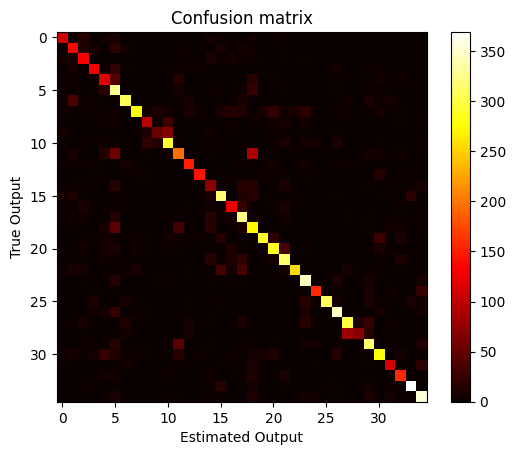

test_Accuracy1 (__main__.TestProgrammingExercise.test_Accuracy1) ... ok
test_Accuracy2 (__main__.TestProgrammingExercise.test_Accuracy2) ... ok
test_F1Score1 (__main__.TestProgrammingExercise.test_F1Score1) ... ok
test_F1Score2 (__main__.TestProgrammingExercise.test_F1Score2) ... ok
test_FalseAlarms1 (__main__.TestProgrammingExercise.test_FalseAlarms1) ... ok
test_FalseAlarms2 (__main__.TestProgrammingExercise.test_FalseAlarms2) ... ok
test_FalseRejections1 (__main__.TestProgrammingExercise.test_FalseRejections1) ... ok
test_FalseRejections2 (__main__.TestProgrammingExercise.test_FalseRejections2) ... ok
test_Precision1 (__main__.TestProgrammingExercise.test_Precision1) ... ok
test_Precision2 (__main__.TestProgrammingExercise.test_Precision2) ... ok
test_Recall1 (__main__.TestProgrammingExercise.test_Recall1) ... ok
test_Recall2 (__main__.TestProgrammingExercise.test_Recall2) ... ok
test_TestdataConfusionMatrix1 (__main__.TestProgrammingExercise.test_TestdataConfusionMatrix1) ... ok
te

In [23]:
def EvalAccuracy(ConfusionMatrix):
    Accuracy = 0.0
    # solution begins
    for n in range(ConfusionMatrix.shape[0]):
        Accuracy += ConfusionMatrix[n, n]
    Accuracy /= np.sum(ConfusionMatrix)
    # solution ends
    return Accuracy

def EvalPrecision(ConfusionMatrix):
    MeanPrecision = 0.0
    # solution begins
    for n in range(ConfusionMatrix.shape[1]):
        precision = ConfusionMatrix[n, n] / np.sum(ConfusionMatrix[:, n])
        MeanPrecision += precision
    MeanPrecision /= ConfusionMatrix.shape[1]
    # solution ends
    return MeanPrecision

def EvalRecall(ConfusionMatrix):
    MeanRecall = 0.0
    # solution begins
    for n in range(ConfusionMatrix.shape[0]):
        recall = ConfusionMatrix[n, n] / np.sum(ConfusionMatrix[n, :])
        MeanRecall += recall
    MeanRecall /= ConfusionMatrix.shape[0]
    # solution ends
    return MeanRecall

def EvalFalseAlarmRate(ConfusionMatrix):
    FalseAlarms = 0.0
    # solution begins
    FalseAlarms = ConfusionMatrix[1,0] / np.sum(ConfusionMatrix)
    # solution ends
    return FalseAlarms

def EvalFalseRejectionRate(ConfusionMatrix):
    FalseRejections = 0.0
    # solution begins
    FalseRejections = ConfusionMatrix[0,1] / np.sum(ConfusionMatrix)
    # solution ends
    return FalseRejections

def EvalF1Score(ConfusionMatrix):
    F1Score = 0.0
    # solution begins
    MeanPrecision = EvalPrecision(ConfusionMatrix)
    MeanRecall = EvalRecall(ConfusionMatrix)
    F1Score = 2/(1/MeanPrecision+1/MeanRecall)
    # solution ends
    return F1Score

def EvaluateConfusionMatrix():
    model = torch.load(ModelFileName, weights_only=False)
    model.eval()
    ConfusionMatrix = torch.zeros(len(labels), len(labels))
    # solution begins
    for n in range(len(test_set)):
        waveform, sample_rate, utterance, *_ = test_set[n]
        label = predict(waveform)
        ConfusionMatrix[label_to_index(utterance), label_to_index(label)] += 1
    # solution ends
    return ConfusionMatrix

ConfusionMatrix = EvaluateConfusionMatrix()
plt.imshow(ConfusionMatrix, cmap='hot', interpolation='nearest')
plt.colorbar()
plt.title('Confusion matrix')
plt.ylabel('True Output')
plt.xlabel('Estimated Output')
plt.show()

import unittest

class TestProgrammingExercise(unittest.TestCase):

    def test_Accuracy1(self):
        ConfusionMatrix = np.array([[7, 2], [3, 6]])
        accuracy = EvalAccuracy(ConfusionMatrix)
        self.assertAlmostEqual(accuracy, 0.722, delta = 1e-3)

    def test_Accuracy2(self):
        ConfusionMatrix = np.array([[9, 5], [1, 4]])
        accuracy = EvalAccuracy(ConfusionMatrix)
        self.assertAlmostEqual(accuracy, 0.684, delta = 1e-3)

    def test_Precision1(self):
        ConfusionMatrix = np.array([[7, 2], [3, 6]])
        precision = EvalPrecision(ConfusionMatrix)
        self.assertAlmostEqual(precision, 0.725, delta = 1e-3)

    def test_Precision2(self):
        ConfusionMatrix = np.array([[9, 5], [1, 4]])
        precision = EvalPrecision(ConfusionMatrix)
        self.assertAlmostEqual(precision, 0.672, delta = 1e-3)

    def test_Recall1(self):
        ConfusionMatrix = np.array([[7, 2], [3, 6]])
        recall = EvalRecall(ConfusionMatrix)
        self.assertAlmostEqual(recall, 0.722, delta = 1e-3)

    def test_Recall2(self):
        ConfusionMatrix = np.array([[9, 5], [1, 4]])
        recall = EvalRecall(ConfusionMatrix)
        self.assertAlmostEqual(recall, 0.721, delta = 1e-3)

    def test_FalseRejections1(self):
        ConfusionMatrix = np.array([[7, 2], [3, 6]])
        FalseRejections = EvalFalseRejectionRate(ConfusionMatrix)
        self.assertAlmostEqual(FalseRejections, 0.111, delta = 1e-3)

    def test_FalseRejections2(self):
        ConfusionMatrix = np.array([[9, 5], [1, 4]])
        FalseRejections = EvalFalseRejectionRate(ConfusionMatrix)
        self.assertAlmostEqual(FalseRejections, 0.263, delta = 1e-3)

    def test_FalseAlarms1(self):
        ConfusionMatrix = np.array([[7, 2], [3, 6]])
        FalseAlarms = EvalFalseAlarmRate(ConfusionMatrix)
        self.assertAlmostEqual(FalseAlarms, 0.167, delta = 1e-3)

    def test_FalseAlarms2(self):
        ConfusionMatrix = np.array([[9, 5], [1, 4]])
        FalseAlarms = EvalFalseAlarmRate(ConfusionMatrix)
        self.assertAlmostEqual(FalseAlarms, 0.053, delta = 1e-3)

    def test_F1Score1(self):
        ConfusionMatrix = np.array([[7, 2], [3, 6]])
        F1Score = EvalF1Score(ConfusionMatrix)
        self.assertAlmostEqual(F1Score, 0.724, delta = 1e-3)

    def test_F1Score2(self):
        ConfusionMatrix = np.array([[9, 5], [1, 4]])
        F1Score = EvalF1Score(ConfusionMatrix)
        self.assertAlmostEqual(F1Score, 0.696, delta = 1e-3)

    def test_TestdataConfusionMatrix1(self):
        accuracy = 0.0
        for i in range(len(labels)):
            accuracy += ConfusionMatrix[i, i]
        accuracy /= len(test_set)
        test_accuracy, test_loss = test_loop(test_dataloader, model, loss_fn)
        self.assertAlmostEqual(accuracy, test_accuracy, delta = 1e-5)

    def test_TestdataConfusionMatrix2(self):
        Counter = torch.zeros(len(labels))
        for n in range(len(test_set)):
            waveform, sample_rate, utterance, *_ = test_set[n]
            Counter[label_to_index(utterance)] += 1
        for n in range(ConfusionMatrix.shape[0]):
            self.assertEqual(torch.sum(ConfusionMatrix[n, :]), Counter[n])

unittest.main(argv=[''], verbosity=2, exit=False)

## Exam Preparation
1) Explain the following words: batch, epoch, training-data, validation-data, test-data, overfitting.

2) You have collected images from three different animals in wildlife: apes (356 images), boars (987 images) and unicorns (1 image taken after a wild student party). What is the accuracy of the simplest possible classificator and what is the output of this simplest possible classificator?

3) The following confusion matrix CM is given. Evaluate the accuracy for this confusion matrix and the recall and precision for each class. Which accuracy can be acchieved by the simplest possible classificator? Is this data set balanced?

4) Pixel values has typically a range of $0..255$. Name a normalisation algorithm in order to normalise the pixel values to a uniform distribution. Name a normalisation algorithm in order to normalise the pixel values to a normal distribution.

In [24]:
CM = np.array([[8, 1, 2], [0, 5, 3], [3, 2, 5]])
print(CM)

[[8 1 2]
 [0 5 3]
 [3 2 5]]


## Summary
After working with this Jupyter Notebook you should be able to explain the following topics:

- What are typical objective measures for classification tasks, and how are they evaluated?
- What are basic design principles for (convolutional) neural networks?
- What is the meaning of the following words: batch, epoch, overfitting, training, validation, testing.
- Name typical preprocessing and normalisation approaches.